In [1]:
import joblib

from phipsurv.io.data_handler import Config, MetadataHandler, OligosHandler, FeatureManager
from phipsurv.plots.metrics_helpers import *
from phipsurv.plots.helpers import  (
    barplot_counts_fisher_test)
from phipsurv.survival.helpers import CoxnetWrapper

In [2]:
config_file = "/home/creyna/Vogl-lab_Projects_git/survival_project/configs/config.yaml"
config = Config(config_file)
# Keep only metadata rows where treatment == "ICI"
config.filters_metadata = {
    "treatment": "ICI",
}
metadata_handler = MetadataHandler(config)
oligos_handler = OligosHandler(config) #, data_type=config.data_types[0])
feature_manager = FeatureManager(config, metadata_handler, oligos_handler,
                                 subgroup = 'all',
                                 with_oligos=True,
                                 with_additional_features = True,
                                 prevalence_threshold_min=0,
                                 prevalence_threshold_max=100)
X_train, y_event_train = feature_manager.get_features_target()
y_time_train = X_train["OS months"]
X_train.drop(columns = ["OS months"], inplace = True)
y_time_train = y_time_train.where(y_event_train == 1, -y_time_train) #np.where(y_event, y_time, -y_time)
number_peptides = X_train.shape[1]
X_train.shape

(73, 8011)

# HCC-TKI internal validation

In [14]:
# Keep only metadata rows where treatment == "TKI"
config.filters_metadata = {
    "treatment": "ICI",
}

metadata_handler = MetadataHandler(config)
oligos_handler = OligosHandler(config)
feature_manager = FeatureManager(config, metadata_handler, oligos_handler,
                                 subgroup = 'all',
                                 with_oligos=True,
                                 with_additional_features = True,
                                 prevalence_threshold_min=0,
                                 prevalence_threshold_max=100)
X_test, y_event_test = feature_manager.get_features_target()
y_time_test = X_test["OS months"]
X_test.drop(columns = ["OS months"], inplace = True)
y_time_test = y_time_test.where(y_event_test == 1, -y_time_test) #np.where(y_event, y_time, -y_time)
X_test.shape

(25, 8011)

In [15]:
out_dir = "/home/creyna/Vogl-lab_Projects_git/HCC/Data/Survival/antigen_score"
config.figures_dir = "/home/creyna/Vogl-lab_Projects_git/HCC/Reports/plots/Figure5"
number_peptides = f"{X_test.shape[1]}"
start, end = 1, 500

In [5]:
# Settings
file_path_template = "/home/creyna/Vogl-lab_Projects_git/HCC/Data/Survival/results/nested_XGB-survivalCox_HCC-ICI_{}.joblib"
top_k = 30
min_freq = 0.5
n_select = 15

# Step 1: gather stats
runs_used, feats, freq_counter, rank_sum, rank_n, mean_abs_sum = process_runs_for_stats(
    file_path_template, start, end, top_k
)

# Step 2: hybrid selection
stats_df, selected_df = hybrid_select(
    feats, runs_used, freq_counter, rank_sum, rank_n, mean_abs_sum,
    min_freq=min_freq, n_select=n_select
)

top_peptides_train = selected_df['feature'].values

Pass 1: stats: 100%|██████████| 500/500 [01:54<00:00,  4.38it/s]

[INFO] Only 13 peptides passed freq ≥ 0.50, relaxing...


In [16]:
top_peptides_train = joblib.load(f"{out_dir}/top_peptides_train.pkl")
top_peptides_train

array(['agilent_26654', 'twist_58791', 'twist_28586', 'agilent_241214',
       'agilent_225378', 'agilent_73606', 'agilent_7108', 'agilent_11270',
       'twist_63959', 'agilent_198784', 'agilent_225587', 'agilent_98303',
       'agilent_73623', 'agilent_235465', 'agilent_219967'], dtype=object)

# Antinge Scores

In [43]:

# ---------- (1) Compute per-run and aggregated antigen scores ----------
def compute_antigen_score_from_joblibs(
    file_path_template: str,
    start: int,
    end: int,
    top_peptides: Iterable[str],
    time_train: pd.Series,
    time_test: pd.Series,
    min_timepoint: int = 1,
    max_timepoint: int = 25,
    agg: str = "median",
    shap_col: str = "train_shap_values",
) -> Tuple[pd.Series, pd.DataFrame, pd.Series]:
    """
    Build antigen scores per sample by summing SHAP over 'top_peptides'
    for each run, then aggregate across runs (mean/median).
    Returns a Series indexed by sample ID: 'Antigen Score'.
    """
    runs = range(start, end + 1)
    time_points =  np.arange(min_timepoint, max_timepoint, step=1)
    per_run_scores = []
    top_peptides = list(map(str, top_peptides))
    time_dependent_auc_antigen_full = pd.DataFrame(None, columns=time_points, index=runs)
    mean_auc_antigen_full = pd.Series(None, index=runs)
    for i in tqdm(runs, desc="Computing per-run antigen scores"):
        path = file_path_template.format(i)
        if not os.path.exists(path):
            continue
        try:
            obj = load(path)
        except Exception as e:
            print(f"[WARN] skipping run {i}: {e}")
            continue
        shap_df = obj.get(shap_col, None)
        if not isinstance(shap_df, pd.DataFrame):
            continue

        shap_df.columns = shap_df.columns.astype(str)
        available = [c for c in top_peptides if c in shap_df.columns]
        if not available:
            continue

        run_scores = shap_df[available].sum(axis=1)

        auc_antigen_values, mean_auc_antigen = calculate_cumulative_dynamic_auc(time_train, time_test, run_scores, time_points)
        time_dependent_auc_antigen_full.loc[i] = auc_antigen_values
        mean_auc_antigen_full.loc[i] = mean_auc_antigen

        run_scores.name = f"run_{i}"
        per_run_scores.append(run_scores)

    if len(per_run_scores) == 0:
        raise RuntimeError("No runs produced antigen scores; check paths and keys.")

    per_run_df = pd.concat(per_run_scores, axis=1)  # align by sample ID
    if agg == "mean":
        antigen_score = per_run_df.mean(axis=1, skipna=True)
    elif agg == "median":
        antigen_score = per_run_df.median(axis=1, skipna=True)
    else:
        raise ValueError("agg must be 'mean' or 'median'")

    antigen_score.name = "Antigen Score"
    return antigen_score, time_dependent_auc_antigen_full, mean_auc_antigen_full

In [17]:
file_path_template = "/home/creyna/Vogl-lab_Projects_git/HCC/Data/Survival/results/validation_XGB-survivalCox_HCC-ICI_HCC-TKI_{}.joblib"
max_time_point_risk = 25
antigen_scores, auc_antigen_values_test_full, mean_auc_antigen_test_full = compute_antigen_score_from_joblibs(
    file_path_template=file_path_template,
    start = start, end = end,
    time_train=y_time_train, time_test=y_time_test,
    top_peptides=top_peptides_train,
    min_timepoint=0,
    max_timepoint=max_time_point_risk,
    agg="median",
    shap_col = 'test_shap_values'
)

Computing per-run antigen scores: 100%|██████████| 500/500 [00:22<00:00, 22.21it/s]


In [18]:
mu = 0.05584122339834023
sig = 0.48688137631359574
antigen_scores_df = pd.DataFrame(antigen_scores, columns = ["Antigen Score"])
antigen_scores_df['Antigen Score (Scaled)'] = (antigen_scores - mu) / sig
antigen_scores_df

,Antigen Score,Antigen Score (Scaled)
SampleName,,
R22P04_47_HCC105_HCC_MUW_A_T_C2,0.154545,0.202726
R22P04_49_HCC126_HCC_MUW_A_T_C2,-0.885373,-1.933149
R22P04_52_HCC232_HCC_MUW_A_T_C2,2.753551,5.540795
R22P04_59_HCC430_HCC_MUW_A_T_C2,2.100550,4.199604
R22P04_62_HCC482_HCC_MUW_A_T_C2,3.190455,6.438147
R22P04_69_HCC677_HCC_MUW_A_T_C2,-0.735292,-1.624900
R22P04_42_HCC31_HCC_MUW_A_T_C2,-0.348048,-0.829544
R22P04_43_HCC54_HCC_MUW_A_T_C2,1.814954,3.613021
R22P04_44_HCC66_HCC_MUW_A_T_C2,2.198848,4.401497


In [19]:
# Step 4: build tidy DF + threshold + saved CSVs
threshold = -0.2684331 #-0.07485386 # previous threshold
antigen_scores_df, threshold, raw_csv, with_cut_csv = build_antigen_score_df(
    antigen_score=antigen_scores_df,
    y_time=y_time_test.abs(),   # OS months
    y_event=y_event_test, # 0/1
    out_dir=out_dir,
    save_prefix="antigen_scores_TKI_RAW",  # customize label
    threshold_method="maxstat",              # or "median"/"percentile"
    percentile=0.5,                          # used only for percentile
    r_seed=1,
    r_B=9999,
    threshold=threshold
)

print("Chosen threshold:", threshold)
print("Saved:", raw_csv, "and", with_cut_csv)
antigen_scores_df

Chosen threshold: -0.2684331
Saved: /home/creyna/Vogl-lab_Projects_git/HCC/Data/Survival/antigen_score/antigen_scores_TKI_RAW.csv and /home/creyna/Vogl-lab_Projects_git/HCC/Data/Survival/antigen_score/antigen_scores_TKI_RAW_with_cut.csv


,OS months,OS Status,Antigen Score,Antigen Score (Scaled),Antigen Score (Dichotomized)
SampleName,,,,,
R22P04_47_HCC105_HCC_MUW_A_T_C2,9.796187,0,0.154545,0.202726,1
R22P04_49_HCC126_HCC_MUW_A_T_C2,18.343195,0,-0.885373,-1.933149,0
R22P04_52_HCC232_HCC_MUW_A_T_C2,9.368836,0,2.753551,5.540795,1
R22P04_59_HCC430_HCC_MUW_A_T_C2,1.610782,0,2.100550,4.199604,1
R22P04_62_HCC482_HCC_MUW_A_T_C2,42.110454,0,3.190455,6.438147,1
R22P04_69_HCC677_HCC_MUW_A_T_C2,21.203156,0,-0.735292,-1.624900,0
R22P04_42_HCC31_HCC_MUW_A_T_C2,9.171598,1,-0.348048,-0.829544,0
R22P04_43_HCC54_HCC_MUW_A_T_C2,1.873767,1,1.814954,3.613021,1
R22P04_44_HCC66_HCC_MUW_A_T_C2,13.050625,1,2.198848,4.401497,1


In [49]:
antigen_scores_df.to_excel(f"{config.figures_dir}/antigen_scores_test_HCC-TKI_{number_peptides}.xlsx", index=True)

## Kaplan Meier

INFO:survival_helpers:Figure saved to /home/creyna/Vogl-lab_Projects_git/HCC/Reports/plots/Figure5/kaplan_meier_testSet_HCC-TKI_8011_newcolors.pdf
INFO:survival_helpers:Log-Rank Test p-value: 0.8917


0.8916949306747782

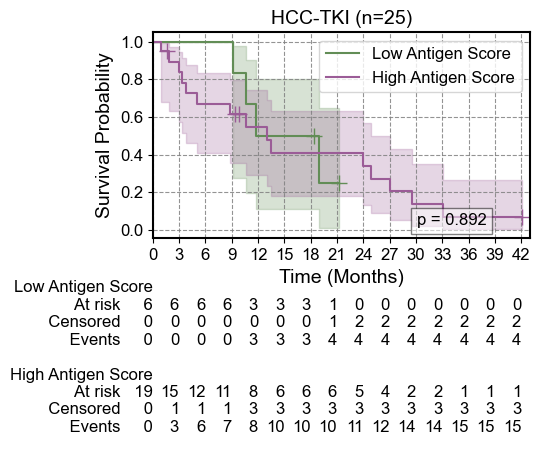

In [20]:
# Assuming the antigen score has been dichotomized into "Antigen Score (Dichotomized)" and you have time and event data in a data frame
labels = {0: 'Low Antigen Score', 1: 'High Antigen Score'}

# Plot for Training Set
plot_kaplan_meier(antigen_scores_df, 'OS months', 'OS Status', 'Antigen Score (Dichotomized)', labels,
                  title="HCC-TKI (n=25)",
                  xlabel="Time (Months)", ylabel="Survival Probability",
                  save_fig=True, figures_dir=config.figures_dir, suffix_file=f'testSet_HCC-TKI_{number_peptides}_newcolors' )

# Perform log-rank test for Training Set
perform_logrank_test(antigen_scores_df, 'OS months', 'OS Status', 'Antigen Score (Dichotomized)')

## Time-dependent AUC

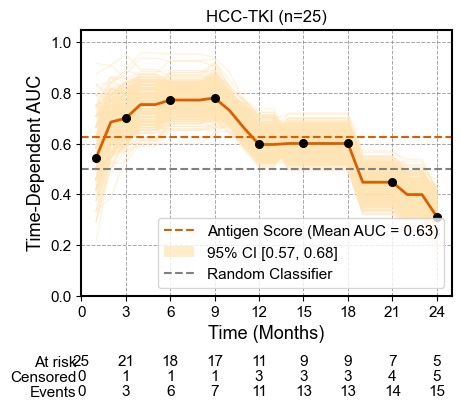

In [148]:
# --- Prep ensemble stats from your 500×T matrix ---
# time_dependent_auc_df: rows=runs (1..500), cols=time points (e.g., 1..24)
max_time_point_plot = 25
auc_matrix = auc_antigen_values_test_full.copy()
#auc_matrix = auc_matrix[:,0:max_time_point_risk]

# 95% pointwise CI across runs
ci_lower = auc_matrix.quantile(0.025, axis=0).values
ci_upper = auc_matrix.quantile(0.975, axis=0).values
ci_lower   = np.asarray(ci_lower, dtype=float)
ci_upper   = np.asarray(ci_upper, dtype=float)
# Mean of per-run mean tAUCs for legend label
# (mean_time_dependent_auc: length-500 Series you already computed)
#mean_auc_label = float(mean_auc_antigen_test_full.mean())


time_points_highlight_test = np.concatenate(([1], np.arange(3, max_time_point_risk, step=3)))
extension_time_points = np.arange(0, max_time_point_plot, step=3)
samples_at_risk_test = calculate_samples_at_risk(y_time_test, extension_time_points)#time_points_highlight_test)


fig = plot_time_dependent_auc(auc_matrix, samples_at_risk_test,
                        mean_auc=mean_auc_antigen_test_full,
                        ci_lower=ci_lower, ci_upper=ci_upper,
                        extension_time_points = extension_time_points,
                        time_points_highlight=time_points_highlight_test,
                        time_measure = "Months", max_time_point = max_time_point_plot,
                        color_auc = "#d95f02", color_mean="#d95f02", color_ci="moccasin",
                        run_lines_color = "moccasin", run_lines_alpha = 0.5,
                        figures_dir = config.figures_dir, save_fig=False)

ax_auc = fig.get_axes()[0]
# Assign new legend
ax_auc.set_title("HCC-TKI (n=25)", fontsize=12)
save_path = Path(config.figures_dir) / f'time-dependent_auc_testSet_HCC-TKI_{number_peptides}_test.pdf'
fig.set_size_inches(4.5, 4)
plt.savefig(save_path, dpi=300, bbox_inches='tight')

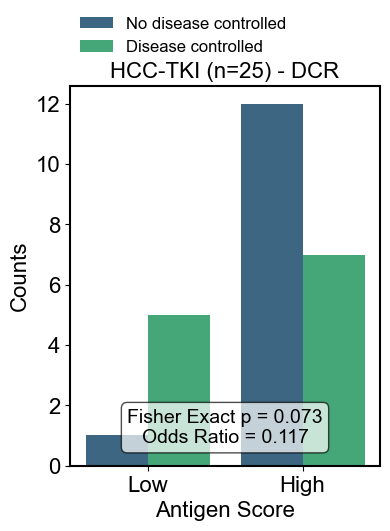

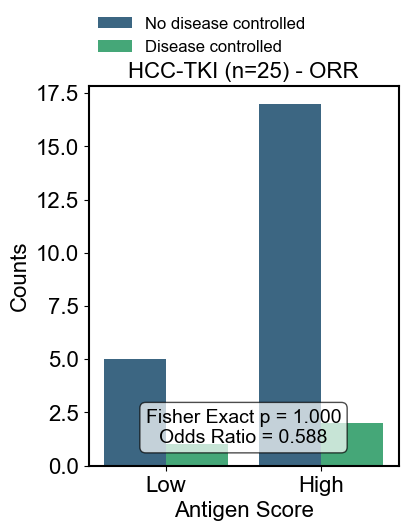

In [26]:
top_peptides_df = feature_manager.get_data_with_target()[top_peptides_train].droplevel(0)
clinical_meta = metadata_handler.get_individuals_metadata_df()
clinical_meta = pd.concat([clinical_meta,
                         pd.concat([antigen_scores_df.iloc[:,2:]], axis=1, names=["SampleName"]), top_peptides_df],  axis = 1)

mapping = {1: 'Disease controlled', 0: 'No disease controlled'}
mapping_antigen = {0: 'Low', 1: 'High'}
fontsize = {"title": 16, "xlabel": 16, "ylabel": 16, "xtick": 16, "ytick": 16,"legend": 14, "annotation": 14}
# Call the function
fig = barplot_counts_fisher_test(
    df=clinical_meta,
    cat_var1='DCR',
    title="HCC-TKI (n=25) - DCR",
    cat_var2='Antigen Score (Dichotomized)',
    legend_title='DCR',
    y_label='Counts',
    x_label='Antigen Score',
    mapping1=mapping,
    mapping2=mapping_antigen,
    figsize=(4, 5.5),
    palette='viridis',
    save_path=config.figures_dir,
    suffix_file=f"validation_HCC-TKI_DCR_{number_peptides}",
    fontsize=fontsize
)
# Call the function
fig = barplot_counts_fisher_test(
    df=clinical_meta,
    title="HCC-TKI (n=25) - ORR",
    cat_var1='ORR',
    cat_var2='Antigen Score (Dichotomized)',
    legend_title='ORR',
    y_label='Counts',
    x_label='Antigen Score',
    mapping1=mapping,
    mapping2=mapping_antigen,
    figsize=(4, 5.5),
    palette='viridis',
    save_path=config.figures_dir,
    suffix_file=f"validation_HCC-TKI_ORR_{number_peptides}",
    fontsize=fontsize
)

# HCC ICI external validation

In [3]:
config.filters_metadata = {'treatment': 'e_ICI'}
metadata_handler = MetadataHandler(config)
oligos_handler = OligosHandler(config) #, data_type=config.data_types[0])
feature_manager = FeatureManager(config, metadata_handler, oligos_handler,
                                 subgroup = 'all',
                                 with_oligos=True,
                                 with_additional_features = True,
                                 prevalence_threshold_min=0,
                                 prevalence_threshold_max=100)
X_test, y_event_test = feature_manager.get_features_target()
y_time_test = X_test["OS months"]
X_test.drop(columns = ["OS months"], inplace = True)
y_time_test = y_time_test.where(y_event_test == 1, -y_time_test) #np.where(y_event, y_time, -y_time)
X_test.shape

(32, 8011)

In [4]:
config.figures_dir = "/home/creyna/Vogl-lab_Projects_git/HCC/Reports/plots/Figure5"
out_dir = "/home/creyna/Vogl-lab_Projects_git/HCC/Data/Survival/antigen_score"
number_peptides = f"{X_test.shape[1]}"
start, end = 1, 500

In [6]:
# Settings
file_path_template = "/home/creyna/Vogl-lab_Projects_git/HCC/Data/Survival/results/nested_XGB-survivalCox_HCC-ICI_{}.joblib"
top_k = 30
min_freq = 0.5
n_select = 15
# gather stats
runs_used, feats, freq_counter, rank_sum, rank_n, mean_abs_sum = process_runs_for_stats(
    file_path_template, start, end, top_k
)

# hybrid selection
stats_df, selected_df = hybrid_select(
    feats, runs_used, freq_counter, rank_sum, rank_n, mean_abs_sum,
    min_freq=min_freq, n_select=n_select
)

top_peptides_train = selected_df['feature'].values

Pass 1: stats: 100%|██████████| 500/500 [00:55<00:00,  9.00it/s]

[INFO] Only 13 peptides passed freq ≥ 0.50, relaxing...


In [5]:
top_peptides_train = joblib.load(f"{out_dir}/top_peptides_train.pkl")
top_peptides_train

array(['agilent_26654', 'twist_58791', 'twist_28586', 'agilent_241214',
       'agilent_225378', 'agilent_73606', 'agilent_7108', 'agilent_11270',
       'twist_63959', 'agilent_198784', 'agilent_225587', 'agilent_98303',
       'agilent_73623', 'agilent_235465', 'agilent_219967'], dtype=object)

## Antigen scores

In [6]:
file_path_template = "/home/creyna/Vogl-lab_Projects_git/HCC/Data/Survival/results/validation_XGB-survivalCox_HCC-ICI_HCC-eICI_{}.joblib"
max_time_point_risk = 11
antigen_scores, auc_antigen_values_test_full, mean_auc_antigen_test_full = compute_antigen_score_from_joblibs(
    file_path_template=file_path_template,
    start = start, end = end,
    time_train=y_time_train, time_test=y_time_test,
    top_peptides=top_peptides_train,
    min_timepoint=0,
    max_timepoint=max_time_point_risk,
    agg="median",
    shap_col = 'test_shap_values'
)

Computing per-run antigen scores: 100%|██████████| 500/500 [00:10<00:00, 45.54it/s]


In [7]:
mu = 0.05584122339834023
sig = 0.48688137631359574

antigen_scores_df = pd.DataFrame(antigen_scores, columns = ["Antigen Score"])
antigen_scores_df['Antigen Score (Scaled)'] = (antigen_scores - mu) / sig
antigen_scores_df

,Antigen Score,Antigen Score (Scaled)
SampleName,,
R38P03_35_TKI005_HCC_A_T_C2,-0.908189,-1.980010
R38P03_40_TKI011_HCC_A_T_C2,0.752734,1.431340
R38P03_45_TKI017_HCC_A_T_C2,-0.779894,-1.716507
R38P03_46_TKI018_HCC_A_T_C2,-0.664922,-1.480367
R38P03_50_TKI022_HCC_A_T_C2,2.181865,4.366615
R38P03_52_TKI025_HCC_A_T_C2,-0.024020,-0.164026
R38P03_54_TKI028_HCC_A_T_C2,1.433661,2.829888
R38P03_55_TKI029_HCC_A_T_C2,-0.178817,-0.481963
R38P03_56_TKI030_HCC_A_T_C2,2.119705,4.238946


In [8]:
# Step 4: build tidy DF + threshold + saved CSVs
out_dir = "/home/creyna/Vogl-lab_Projects_git/HCC/Data/Survival/antigen_score"
threshold = -0.2684331 #-0.07485386 raw threshold
antigen_scores_df, threshold, raw_csv, with_cut_csv = build_antigen_score_df(
    antigen_score=antigen_scores_df,
    y_time=y_time_test.abs(),   # OS months
    y_event=y_event_test, # 0/1
    out_dir=out_dir,
    save_prefix="antigen_scores_eICI_RAW_32samples",  # customize label
    threshold_method="maxstat",              # or "median"/"percentile"
    percentile=0.5,                          # used only for percentile
    r_seed=1,
    r_B=9999
    ,threshold=threshold
)

print("Chosen threshold:", threshold)
print("Saved:", raw_csv, "and", with_cut_csv)
antigen_scores_df.to_excel(f"{config.figures_dir}/antigen_scores_test_HCC-eICI_{number_peptides}_32samples.xlsx", index=True)
antigen_scores_df

Chosen threshold: -0.2684331
Saved: /home/creyna/Vogl-lab_Projects_git/HCC/Data/Survival/antigen_score/antigen_scores_eICI_RAW_32samples_example.csv and /home/creyna/Vogl-lab_Projects_git/HCC/Data/Survival/antigen_score/antigen_scores_eICI_RAW_32samples_example_with_cut.csv


,OS months,OS Status,Antigen Score,Antigen Score (Scaled),Antigen Score (Dichotomized)
SampleName,,,,,
R38P03_35_TKI005_HCC_A_T_C2,29.030137,0,-0.908189,-1.980010,0
R38P03_40_TKI011_HCC_A_T_C2,51.221918,0,0.752734,1.431340,1
R38P03_45_TKI017_HCC_A_T_C2,4.602740,0,-0.779894,-1.716507,0
R38P03_46_TKI018_HCC_A_T_C2,1.183562,0,-0.664922,-1.480367,0
R38P03_50_TKI022_HCC_A_T_C2,39.090411,0,2.181865,4.366615,1
R38P03_52_TKI025_HCC_A_T_C2,9.764384,0,-0.024020,-0.164026,1
R38P03_54_TKI028_HCC_A_T_C2,41.753425,0,1.433661,2.829888,1
R38P03_55_TKI029_HCC_A_T_C2,39.682192,0,-0.178817,-0.481963,0
R38P03_56_TKI030_HCC_A_T_C2,37.972603,0,2.119705,4.238946,1


## Kaplan Meier curve

INFO:survival_helpers:Figure saved to /home/creyna/Vogl-lab_Projects_git/HCC/Reports/plots/Figure5/kaplan_meier_externalSet_HCC-eICI_8011_newcolors.pdf
INFO:survival_helpers:Log-Rank Test p-value: 0.1341


0.13408291798638053

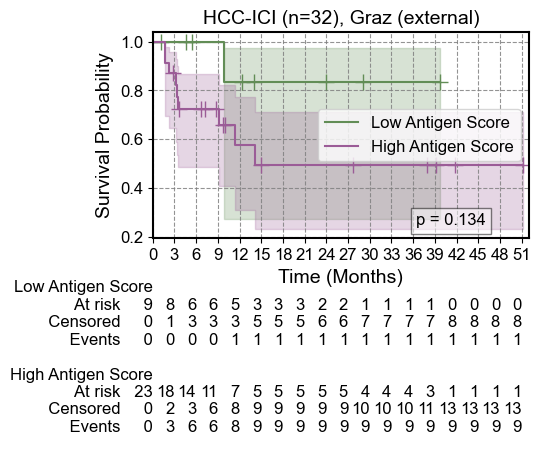

In [27]:
# Assuming the antigen score has been dichotomized into "Antigen Score (Dichotomized)" and you have time and event data in a data frame
labels = {0: 'Low Antigen Score', 1: 'High Antigen Score'}

# Plot for Training Set
plot_kaplan_meier(antigen_scores_df, 'OS months', 'OS Status', 'Antigen Score (Dichotomized)', labels,
                  title="HCC-ICI (n=32), Graz (external)",
                  xlabel="Time (Months)", ylabel="Survival Probability",
                  save_fig=True, figures_dir=config.figures_dir, suffix_file=f'externalSet_HCC-eICI_{number_peptides}_newcolors' )

# Perform log-rank test for Training Set
perform_logrank_test(antigen_scores_df, 'OS months', 'OS Status', 'Antigen Score (Dichotomized)')

In [9]:
antigen_scores_df

,OS months,OS Status,Antigen Score,Antigen Score (Scaled),Antigen Score (Dichotomized)
SampleName,,,,,
R38P03_35_TKI005_HCC_A_T_C2,29.030137,0,-0.908189,-1.980010,0
R38P03_40_TKI011_HCC_A_T_C2,51.221918,0,0.752734,1.431340,1
R38P03_45_TKI017_HCC_A_T_C2,4.602740,0,-0.779894,-1.716507,0
R38P03_46_TKI018_HCC_A_T_C2,1.183562,0,-0.664922,-1.480367,0
R38P03_50_TKI022_HCC_A_T_C2,39.090411,0,2.181865,4.366615,1
R38P03_52_TKI025_HCC_A_T_C2,9.764384,0,-0.024020,-0.164026,1
R38P03_54_TKI028_HCC_A_T_C2,41.753425,0,1.433661,2.829888,1
R38P03_55_TKI029_HCC_A_T_C2,39.682192,0,-0.178817,-0.481963,0
R38P03_56_TKI030_HCC_A_T_C2,37.972603,0,2.119705,4.238946,1


In [12]:
# Fit Kaplan–Meier model for this group
kmf = KaplanMeierFitter()
kmf.fit(antigen_scores_df['OS months'], event_observed=antigen_scores_df['OS Status'], label="Antigen Score (Dichotomized)")
# Calculate median survival and 95% CI using a helper function.
median_survival = kmf.median_survival_time_
ci_df = median_survival_times(kmf.confidence_interval_)  # user-defined function
ci_lower, ci_upper = ci_df.iloc[0, 0], ci_df.iloc[0, 1]
ci_upper

inf

In [23]:
def compute_median_os(df, time_col, status_col, group_col):
    results = []

    for group_value, group_df in df.groupby(group_col):
        km = KaplanMeierFitter()
        km.fit(
            durations=group_df[time_col],
            event_observed=group_df[status_col],
            label=str(group_value)
        )

        # Median OS
        median_os = km.median_survival_time_

        # Median CI (works with lifelines>=0.27 automatically)
        try:
            median_survival_times(kmf.confidence_interval_)
            ci_df = median_survival_times(kmf.confidence_interval_)  # user-defined function
            ci_lower, ci_upper = ci_df.iloc[0, 0], ci_df.iloc[0, 1]
        except:
            ci_lower, ci_upper = np.nan, np.nan

        results.append({
            "Group": group_value,
            "Median OS": median_os,
            "Median OS 95% CI Lower": ci_lower,
            "Median OS 95% CI Upper": ci_upper
        })
    return pd.DataFrame(results)

median_results = compute_median_os(
    antigen_scores_df,
    'OS months',
    'OS Status',
    'Antigen Score (Dichotomized)'
)

print(median_results)

   Group  Median OS  Median OS 95% CI Lower  Median OS 95% CI Upper
0      0        inf                9.863014                     inf
1      1   14.10411                9.863014                     inf


 ## Time-dependent AUC

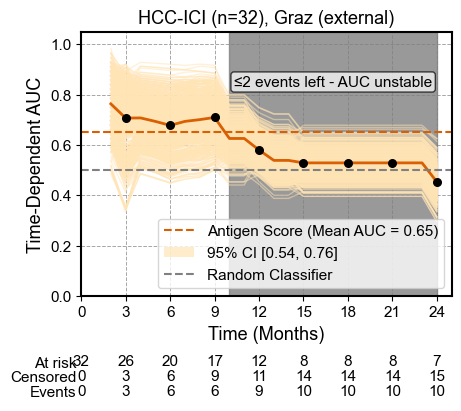

In [192]:
# --- Prep ensemble stats from your 500×T matrix ---
# time_dependent_auc_df: rows=runs (1..500), cols=time points (e.g., 1..24)
max_time_point_plot = 25
auc_matrix =  auc_antigen_values_test_full.copy()

# 95% pointwise CI across runs
ci_lower = auc_matrix.quantile(0.025, axis=0).values
ci_upper = auc_matrix.quantile(0.975, axis=0).values
ci_lower   = np.asarray(ci_lower, dtype=float)
ci_upper   = np.asarray(ci_upper, dtype=float)
# Mean of per-run mean tAUCs for legend label
# (mean_time_dependent_auc: length-500 Series you already computed)

time_points_highlight_test = np.concatenate(([1], np.arange(3, max_time_point_risk, step=3)))
extension_time_points = np.arange(0, max_time_point_plot, step=3)
samples_at_risk_test = calculate_samples_at_risk(y_time_test, extension_time_points)#time_points_highlight_test)


fig = plot_time_dependent_auc(auc_matrix, samples_at_risk_test,
                        mean_auc=mean_auc_antigen_test_full,
                        ci_lower=ci_lower, ci_upper=ci_upper,
                        extension_time_points = extension_time_points,
                        time_points_highlight=time_points_highlight_test,
                        time_measure = "Months", max_time_point = max_time_point_plot,
                        color_auc = "#d95f02", color_mean="#d95f02", color_ci="moccasin",
                        run_lines_color = "moccasin", run_lines_alpha = 0.5, run_linewidth = 1,
                        figures_dir = config.figures_dir, save_fig=False)

ax_auc = fig.get_axes()[0]
cutoff = 10
n_events_tail = int(((antigen_scores_df['OS months'] >= 10) & (antigen_scores_df['OS Status'] == 1)).sum())
ax_auc.set_title("HCC-ICI (n=32), Graz (external)", fontsize=13)
ax_auc.axvspan(cutoff, max_time_point_risk-1, color="gray", alpha=0.8, zorder=0)
# text to display
label = f"≤{n_events_tail} events left - AUC unstable" #f"≤1 events – AUC unstable" if n_events_tail <= 1 else f"≤{n_events_tail} events – interpret cautiously"
# place text centered in the shaded area
xmid = (cutoff + max_time_point_risk-1) / 2.0
ax_auc.text(
    xmid, 0.85, label,
    ha='center', va='center',
    fontsize=11, color='black',
    bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.2'),
    zorder=3
)

save_path = Path(config.figures_dir) / f'time-dependent_auc_testSet_HCC-eICI_{number_peptides}_warning.pdf'
fig.set_size_inches(4.5, 4)
plt.savefig(save_path, dpi=300, bbox_inches='tight')

In [193]:
top_peptides_df = feature_manager.get_data_with_target()[top_peptides_train].droplevel(0)
clinical_meta = metadata_handler.get_individuals_metadata_df()
clinical_meta = pd.concat([clinical_meta,
                         pd.concat([antigen_scores_df.iloc[:,2:]], axis=1, names=["SampleName"]), top_peptides_df],  axis = 1)
clinical_meta

,Etiology,treatment,subtreatment,group_test,Sex,Age,Centre,ORR,ORR_ctg,DCR,...,agilent_73606,agilent_7108,agilent_11270,twist_63959,agilent_198784,agilent_225587,agilent_98303,agilent_73623,agilent_235465,agilent_219967
SampleName,,,,,,,,,,,,,,,,,,,,,
R38P03_34_TKI003_HCC_A_T_C2,MASH,e_ICI,e_ICI,HCC,1,70.0,Graz,NaN,NaN,NaN,...,0,1,0,0,0,0,0,1,0,1
R38P03_35_TKI005_HCC_A_T_C2,Other,e_ICI,e_ICI,HCC,1,69.0,Graz,0.0,non ORR,1.0,...,0,1,0,0,0,0,0,0,1,0
R38P03_40_TKI011_HCC_A_T_C2,NaN,e_ICI,e_ICI,HCC,1,66.0,Graz,1.0,ORR,1.0,...,0,1,0,0,1,0,0,0,0,0
R38P03_44_TKI016_HCC_A_T_C2,Viral,e_ICI,e_ICI,HCC,0,61.0,Graz,0.0,non ORR,1.0,...,0,1,0,0,0,1,0,0,1,0
R38P03_45_TKI017_HCC_A_T_C2,MASH,e_ICI,e_ICI,HCC,1,80.0,Graz,0.0,non ORR,0.0,...,0,0,1,0,0,0,0,0,0,0
R38P03_46_TKI018_HCC_A_T_C2,Alcohol,e_ICI,e_ICI,HCC,1,72.0,Graz,NaN,NaN,NaN,...,0,1,1,0,0,0,0,0,0,1
R38P03_50_TKI022_HCC_A_T_C2,Alcohol,e_ICI,e_ICI,HCC,1,57.0,Graz,1.0,ORR,1.0,...,0,0,0,0,0,0,0,0,0,0
R38P03_51_TKI023_HCC_A_T_C2,Viral,e_ICI,e_ICI,HCC,1,67.0,Graz,0.0,non ORR,1.0,...,0,0,1,0,1,0,0,0,1,0
R38P03_52_TKI025_HCC_A_T_C2,MASH,e_ICI,e_ICI,HCC,1,77.0,Graz,0.0,non ORR,1.0,...,0,1,0,0,1,0,0,0,0,1


In [71]:
combined = pd.read_csv("/home/creyna/Vogl-lab_Projects_git/Annotations/combined_libraries_with_lineages_important_info_withFullAAseq.csv")
combined

/tmp/ipykernel_1755320/3799385731.py:1: DtypeWarning: Columns (1,2,3,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,28,29,30,31,33) have mixed types. Specify dtype option on import or set low_memory=False.
  combined = pd.read_csv("/home/creyna/Vogl-lab_Projects_git/Annotations/combined_libraries_with_lineages_important_info_withFullAAseq.csv")


,Unnamed: 0,pos,len_seq,full name,Description,is_IEDB_or_cntrl,is_auto,is_infect,is_EBV,is_toxin,...,order,family,genus,species,common,allergens_species,allergens_common_name,allergens_comments,aa_seq,full_aa_seq
0,agilent_0,0,0.0,FLAG-tag control,NaN,True,False,False,False,False,...,NaN,NaN,NaN,NaN,NaN,False,False,False,DYKDDDDK,DYKDDDDK
1,agilent_1,2728,2997.0,Chromodomain-helicase-DNA-binding protein 7,Chromodomain-helicase-DNA-binding protein 7,True,True,False,False,False,...,Primates,Hominidae,Homo,Homo sapiens,Human,False,False,False,AAAAAAVASTSGINPLLVNSLFAGMDLTSLQNLQNLQSLQLAGLMG...,MADPGMMSLFGEDGNIFSEGLEGLGECGYPENPVNPMGQQMPIDQG...
2,agilent_2,88,445.0,integral membrane protein,Uncharacterized MFS-type transporter Rv2994,True,False,True,False,False,...,Mycobacteriales,Mycobacteriaceae,Mycobacterium,Mycobacterium tuberculosis,NaN,False,False,False,AAAAYAAASVHSLLWIGVFLFLGGMAAGGCNSAGGRLVSGWFPPQQ...,MSRDPTGVGARWAIMIVSLGVTASSFLFINGVAFLIPRLENARGTP...
3,agilent_3,264,548.0,hypothetical protein (6/16) & membrane protein...,Possible conserved membrane protein,True,False,True,False,False,...,Mycobacteriales,Mycobacteriaceae,Mycobacterium,Mycobacterium tuberculosis,NaN,False,False,False,AAADRSAPLSRRSLLIGNAVVAFAVIGFASLAVAVAVTIRPTAASK...,MDVALGVAVTDRVARLALVDSAAPGTVIDQFVLDVAEHPVEVLTET...
4,agilent_4,1276,3432.0,envelope protein (5/8) & anchored core protein...,Genome polyprotein,True,False,True,False,False,...,Amarillovirales,Flaviviridae,Orthoflavivirus,Orthoflavivirus japonicum,JEV,False,False,False,AAAIAWMIVRAITFPTTSSVTMPVLALLTPGMRALYLDTYRIILLV...,MTKKPGGPGKNRAINMLKRGLPRVFPLVGVKRVVMSLLDGRGPVRF...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357187,corona2_13187,0,0,random sequence 37,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TGGILDDMLLDMPQRFASVHHIMCTFMSPGTVDCVRQEMDMNYWSQ...,NaN
357188,corona2_13188,0,0,random sequence 2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TWHSPHVMHVPQSNQHKDLYYVSGYDVRMEQQPLTTQNQMFVNWWS...,NaN
357189,corona2_13189,0,0,random sequence 17,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VIQTMHQNTWYVPVRAEERGFYSCMTLIGIPDWFYFDIRSRNCFPG...,NaN
357190,corona2_13190,0,0,random sequence 10,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WDVNDCSNNRKTKNPAGHNPCANFPYGGKWNLWDSFERFELPIMTM...,NaN


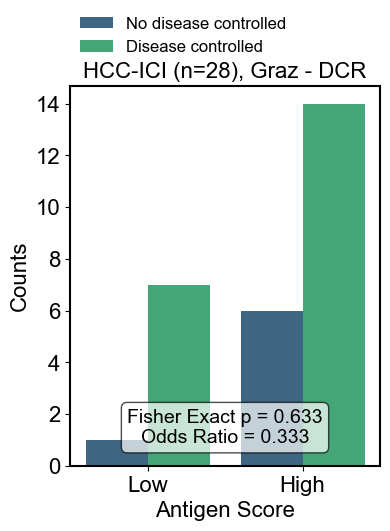

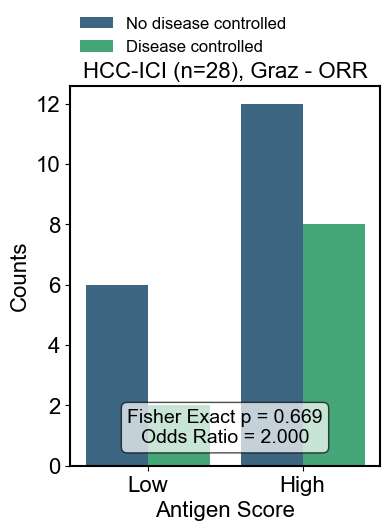

In [196]:
mapping = {1: 'Disease controlled', 0: 'No disease controlled'}
mapping_antigen = {0: 'Low', 1: 'High'}
fontsize = {"title": 16, "xlabel": 16, "ylabel": 16, "xtick": 16, "ytick": 16,"legend": 14, "annotation": 14}
# Call the function
fig = barplot_counts_fisher_test(
    df=clinical_meta,
    cat_var1='DCR',
    title="HCC-ICI (n=28), Graz - DCR",
    cat_var2='Antigen Score (Dichotomized)',
    legend_title='DCR',
    y_label='Counts',
    x_label='Antigen Score',
    mapping1=mapping,
    mapping2=mapping_antigen,
    figsize=(4, 5.5),
    palette='viridis',
    save_path=config.figures_dir,
    suffix_file=f"validation_HCC-eICI_DCR_{number_peptides}",
    fontsize=fontsize
)
# Call the function
fig = barplot_counts_fisher_test(
    df=clinical_meta,
    title="HCC-ICI (n=28), Graz - ORR",
    cat_var1='ORR',
    cat_var2='Antigen Score (Dichotomized)',
    legend_title='ORR',
    y_label='Counts',
    x_label='Antigen Score',
    mapping1=mapping,
    mapping2=mapping_antigen,
    figsize=(4, 5.5),
    palette='viridis',
    save_path=config.figures_dir,
    suffix_file=f"validation_HCC-eICI_ORR_{number_peptides}",
    fontsize=fontsize
)